# Comparision of different PRNGs (Model 1)

The Python code in this notebook will load the simulation results stored in the `statistics` folder and will generate the boxplots for model 1 shown in the report.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

plt.style.use('seaborn-v0_8')

## Select input file to load

In [2]:
# input_file="statistics/results1Exp.txt"
# mean=200
# std=200

input_file="statistics/results1Log.txt"
mean=200
std=50

# input_file="statistics/results1Gamma.txt"
# mean=200
# std=50

# input_file="statistics/results1Triangular.txt"
# mean=200
# std=50

## Load and process data

In [3]:
df = pd.read_csv(input_file, header=None, names=["rng_mode", "n", "mean", "std", "delta2", "time"], sep="\t")

In [4]:
generators=df["rng_mode"].drop_duplicates().tolist()
generators.remove("ThreadLocalRandomSlow")  # This is the same a "ThreadLocalRandom". Only used for speed comparision. Removed from other tables.

### Colors for generator types

In [5]:
def color_from_name(name):
    if name in ['SecureRandom', 'ISAAC']:
        return 'blue'
    if name in ['Drand48', 'Drand48Mix']:
        return 'red'
    return 'black'

def color_labels(ax):
    for label in ax.get_xticklabels():
        label.set_color(color_from_name(label.get_text()))

def color_boxes(ax):
    for i, generator in enumerate(generators):
        c = color_from_name(generator)
        if c == 'black':
            continue
        ax.axvspan(0.5+i, 1.5+i, facecolor=c, alpha=0.1, edgecolor='none', zorder=-10)

def color_all(fig):
    axes = fig.axes
    for ax in axes:
        color_boxes(ax)
    color_labels(axes[-1])

## Boxplot for all data (not used in the report)

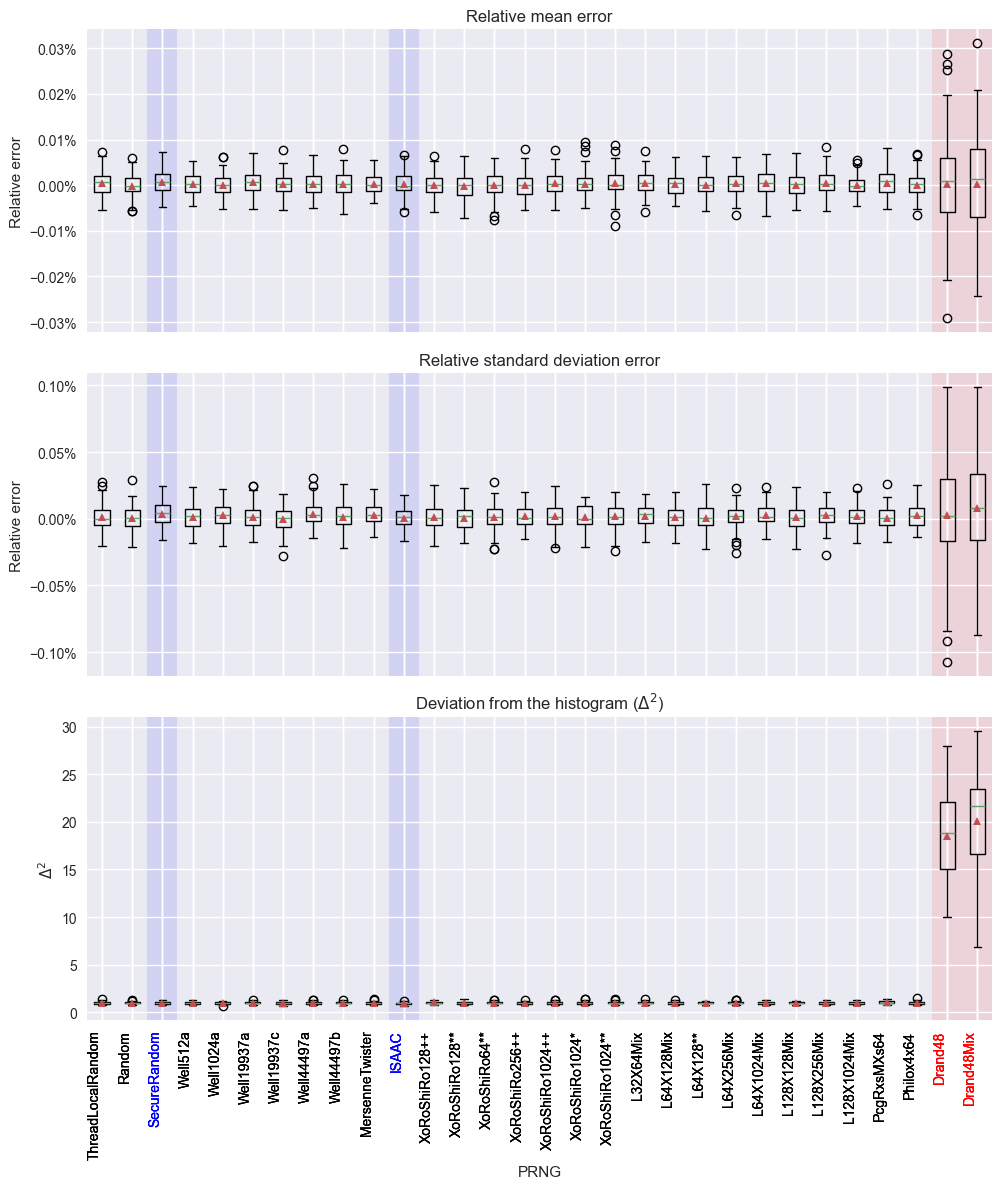

In [ ]:
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(10, 12), sharex='col')

ax1.boxplot([(df[df["rng_mode"] == generator]["mean"]-mean)/mean*100 for generator in generators], showmeans=True)
ax2.boxplot([(df[df["rng_mode"] == generator]["std"]-std)/std*100 for generator in generators], showmeans=True)
ax3.boxplot([df[df["rng_mode"] == generator]["delta2"]*100_000_000 for generator in generators], showmeans=True)
ax3.set_xticklabels(generators + generators + generators, rotation=90, ha='right')

ax1.set_title("Relative mean error")
ax1.set_ylabel("Relative error")
ax2.set_title("Relative standard deviation error")
ax2.set_ylabel("Relative error")
ax3.set_title("Deviation from the histogram ($\\Delta^2$)")
ax3.set_xlabel("PRNG")
ax3.set_ylabel("$\\Delta^2$")
color_all(fig)

fig.tight_layout()

ax1.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=2))
ax2.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=2))

# fig.savefig("plot1boxplots-LogNormal.png", format="png", bbox_inches='tight', pad_inches=0)

## Relative mean error and relative standard deviation error

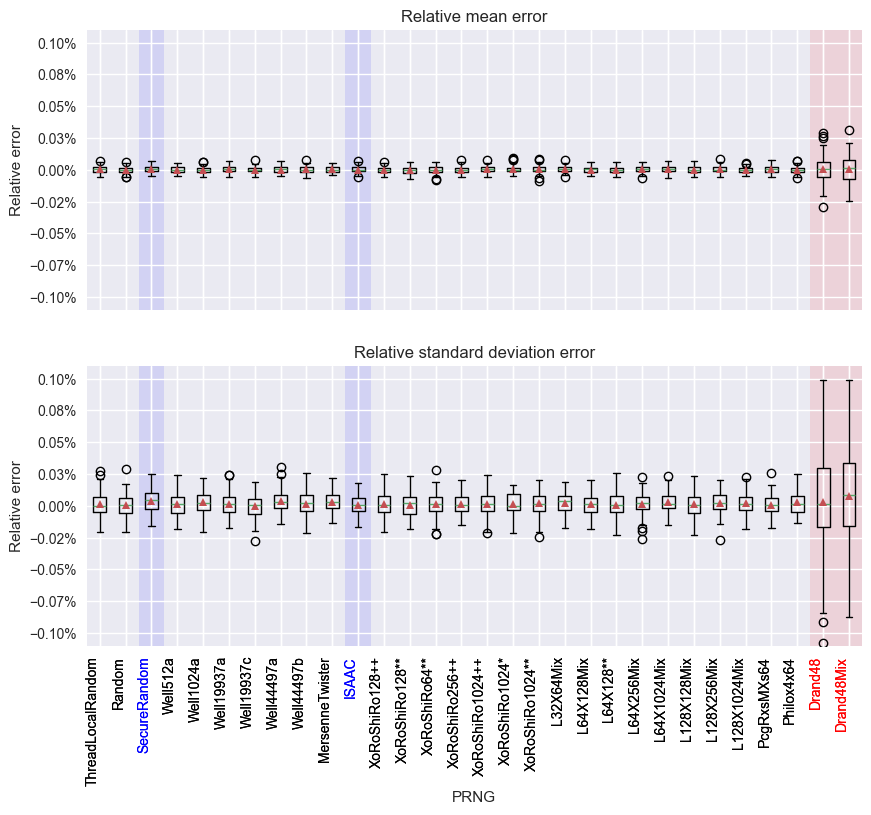

In [ ]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex='col')

ax1.boxplot([(df[df["rng_mode"] == generator]["mean"]-mean)/mean*100 for generator in generators], showmeans=True)
ax2.boxplot([(df[df["rng_mode"] == generator]["std"]-std)/std*100 for generator in generators], showmeans=True)
ax2.set_xticklabels(generators + generators, rotation=90, ha='right')

ax1.set_title("Relative mean error")
ax1.set_ylabel("Relative error")
ax2.set_title("Relative standard deviation error")
ax2.set_xlabel("PRNG")
ax2.set_ylabel("Relative error")

ax1.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=2))
ax2.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=2))

ax1.set_ylim((-0.11,0.11))
ax2.set_ylim((-0.11,0.11))

color_all(fig)

# fig.savefig("plot1boxplots.pdf", format="pdf", bbox_inches='tight', pad_inches=0)